# IPA27 - Fase 2: Modelación y Transformación de Series Temporales



Este notebook constituye el **segundo bloque** del pipeline de procesamiento del **Índice de Prosperidad Andaluz (IPA27)**.



### Funciones de este bloque:

1. **Carga de Datos Preparados**: Importación de los DataFrames mensuales, trimestrales y anuales preprocesados por la Fase 1 (`data/processed/ipa27_prep_*.csv`).

2. **Desestacionalización**: Tratamiento de componentes estacionales mediante STL (Seasonal-Trend decomposition using LOESS) en series mensuales y trimestrales, incluyendo la detección y sustitución de outliers.

3. **Trimestralización**: Desagregación temporal de indicadores anuales a trimestrales usando Chow-Lin AR(1) con indicador de referencia o Denton (spline cúbico) en su ausencia.

4. **Nowcasting (Extensión ARIMA)**: Extensión automática de las series hasta el trimestre objetivo (`2026Q1`) mediante modelos ARIMA (`pmdarima`).

5. **Suavizado Temporal**: Aplicación de medias móviles de 4 periodos a indicadores con alta volatilidad (ej. `INV_IED` y `GOB_EFF`) para estabilizar los agregados.

6. **Normalización Per Cápita**: Transformación de las variables absolutas a tasas relativas dividiendo entre la población (`AUX_POB` o `AUX_POB_enlazado`) con factores de escala (por 100k hab, por 1k hab, etc.).

7. **Unificación final**: Consolidación de todos los indicadores en un único dataset trimestral en unidades físicas/brutas (`df_trim`).



Al finalizar, se exporta el DataFrame unificado a `data/processed/ipa27_modeled_raw.csv` para ser consumido por el bloque de agregación y exportación final (`02_3_exportacion.ipynb`).


## 📁 0. Respaldo Automático de Procesados Previos (Gobernanza de Históricos)

Antes de ejecutar la modelación (Chow-Lin y Nowcasting ARIMA) con los nuevos datos, esta sección resguarda en la carpeta de gobernanza histórica cualquier resultado procesado previo (`data/processed/ipa27_modeled_raw.csv`), asegurando la trazabilidad absoluta del modelo.

In [1]:
# %% CELDA 0B: RESPALDO DE PROCESADOS HISTÓRICOS PREVIOS
import os
import glob
import shutil
import re

# Asegurar que trabajamos desde la raíz del proyecto
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print("=" * 60)
print("🛡️ GOBERNANZA DE HISTÓRICOS: RESPALDO DE EJECUCIONES ANTERIORES")
print("=" * 60)

raw_files = sorted(glob.glob('results/data/ipa27_raw_*.xlsx'))

if len(raw_files) >= 2:
    prev_raw = raw_files[-2]
    curr_raw = raw_files[-1]
    
    match = re.search(r'ipa27_raw_(\d+)\.xlsx', os.path.basename(prev_raw))
    prev_tag = match.group(1) if match else os.path.basename(prev_raw).replace('.xlsx', '')
    
    backup_dir = os.path.join('data', 'processed_history', f'ipa27_raw_{prev_tag}')
    processed_dir = os.path.join('data', 'processed')
    
    if os.path.exists(processed_dir):
        files_to_backup = [f for f in os.listdir(processed_dir) if os.path.isfile(os.path.join(processed_dir, f))]
        
        if files_to_backup:
            os.makedirs(backup_dir, exist_ok=True)
            for file_name in files_to_backup:
                src = os.path.join(processed_dir, file_name)
                dst = os.path.join(backup_dir, file_name)
                # Copiar solo si no existe ya o si difiere
                dst_path = os.path.join(backup_dir, file_name)
                if not os.path.exists(dst_path):
                    shutil.copy2(src, dst_path)
            print(f"📦 Respaldo histórico actualizado en: '{backup_dir}'")
            print(f"   Archivos resguardados ({len(files_to_backup)}): {files_to_backup}")
        else:
            print(f"ℹ️ La carpeta '{processed_dir}' está vacía. No hay archivos previos que respaldar.")
    else:
        print(f"ℹ️ No existe la carpeta '{processed_dir}'. Se creará nueva en esta ejecución.")
        
    print(f"📌 Raw Anterior Resguardado: {os.path.basename(prev_raw)}")
    print(f"🚀 Raw Activo para esta Ejecución: {os.path.basename(curr_raw)}")
else:
    print(f"ℹ️ No se detectó un archivo raw previo para respaldar en {os.getcwd()}.")

🛡️ GOBERNANZA DE HISTÓRICOS: RESPALDO DE EJECUCIONES ANTERIORES
📦 Respaldo histórico actualizado en: 'data\processed_history\ipa27_raw_20260603'
   Archivos resguardados (9): ['Banda_Ancha.csv', 'IPA27_Master_Table.csv', 'IPA27_Results.xlsx', 'ipa27_prep_mensual.csv', 'ipa27_prep_trimestral.csv', 'ipa27_prep_anual.csv', 'ipa27_modeled_raw.csv', 'ipa27_audit_registry.pkl', 'cgpj_violencia_mujer.csv']
📌 Raw Anterior Resguardado: ipa27_raw_20260603.xlsx
🚀 Raw Activo para esta Ejecución: ipa27_raw_20260820.xlsx


In [2]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy.interpolate import CubicSpline
from datetime import datetime

warnings.filterwarnings('ignore')

# Asegurar que trabajamos desde la raíz del proyecto
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
    print(f"🏠 Directorio de trabajo: {os.getcwd()}")

# Configuración visual
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 9

# === REGIONES (17 CCAA + ESPAÑA) ===
REGIONES = ['ESP', 'AND', 'ARA', 'AST', 'BAL', 'CAN', 'CANT', 'CYL', 'CLM', 'CAT', 'VAL', 'EXT', 'GAL', 'MAD', 'MUR', 'NAV', 'PV', 'RIO']

# === RUTAS ===
def get_latest_vintage():
    files = glob.glob('results/data/ipa27_raw_*.xlsx')
    if not files:
        fallback = 'results/data/ipa27_raw.xlsx'
        return fallback if os.path.exists(fallback) else None
    return sorted(files)[-1]

FILEPATH = get_latest_vintage()
if FILEPATH:
    print(f"📂 Utilizando vintage: {FILEPATH}")
else:
    print("❌ No se encontró ningún archivo ipa27_raw_*.xlsx en results/data/")

# === OBJETIVO TEMPORAL ===
Q_OBJETIVO = pd.Period('2026Q2', freq='Q')

# === INDICADORES A DESESTACIONALIZAR ===
DESEST_MENSUAL = ['EMP_SOC', 'INF_TRA', 'INV_HIP', 'SOC_ASO', 'CON_OCI']
DESEST_TRIMESTRAL = ['ECO_COL_sal','LIB_SEX', 'SEG_BAL', 'SEG_CRI', 'VID_PAR']

# === NORMALIZACIÓN PER CÁPITA ===
PER_CAPITA_CONFIG = {
    'SEG_BAL': 'POB',
    'SEG_CRI': 'POB',
    'LIB_SEX': 'POB',
    'LIB_ODI': 'POB',
    'EDU_SUP': 'POB',
    'EMP_SOC': 'POB',
    'EMP_NAT': 'POB',
    'INV_HIP': 'POB',
    'INF_TRA': 'POB',
    'SOC_ASO': 'POB',
    'CON_OCI': 'POB',   # ← CAMBIADO: Afiliados = personas, dividir por población
    'INV_IED': 'PIB',   # Mantener, pero arreglar la lógica abajo
}

# === CHOW-LIN: INDICADORES RELACIONADOS ===
CHOWLIN_CONFIG = {
    'CON_IDI': {'rel': 'ECO_RBHpc', 'tipo': 'stock'},      # % PIB → media
    'EDU_ABA': {'rel': 'EDU_SUP', 'tipo': 'stock'},      # % abandono → media
    'EMP_NAT': {'rel': 'INF_TRA', 'tipo': 'flujo'},      # nacimientos → suma
    'INF_BAN': {'rel': 'EDU_SUP', 'tipo': 'stock'},      # % bancarización → media
    'LIB_ODI': {'rel': 'SEG_CRI', 'tipo': 'flujo'},      # delitos → suma
    'SAL_ESP': {'rel': 'ECO_RBHpc', 'tipo': 'stock'},      # años vida → media
    'SOC_PAR_enlazado': {'rel': 'EMP_SOC', 'tipo': 'stock'},  # % participación → media
    'VID_ARO': {'rel': 'EDU_SUP', 'tipo': 'stock'},      # % AROPE → media
}

# === INDICADORES A INVERTIR (menor es mejor) ===
INVERTIR = ['SEG_BAL', 'SEG_CRI', 'LIB_ODI', 'LIB_SEX', 'GOB_EFF', 'GOB_DES']

# === ESTRUCTURA JERÁRQUICA ===
# Corrección: Usamos GOB_EFF en lugar de GOB_TRA
ESTRUCTURA = {
    'Sociedades Inclusivas': {
        '1. Seguridad': ['SEG_BAL', 'SEG_CRI'],
        '2. Libertad': ['LIB_ODI', 'LIB_SEX'],
        '3. Gobernanza': ['GOB_DES', 'GOB_EFF'],
        '4. Capital Social': ['SOC_ASO', 'SOC_PAR_enlazado'],
    },
    'Economías Abiertas': {
        '5. Inversión': ['INV_HIP', 'INV_IED'],
        '6. Empresas': ['EMP_NAT', 'EMP_SOC'],
        '7. Infraestructura': ['INF_BAN', 'INF_TRA'],
        '8. Calidad Económica': ['ECO_RBHpc', 'ECO_COL_sal'], 
    },
    'Personas Empoderadas': {
        '9. Vida': ['VID_ARO', 'VID_PAR'],
        '10. Salud': ['SAL_ESP', 'SAL_SAT_enlazado'],
        '11. Educación': ['EDU_ABA', 'EDU_SUP'],
        '12. Conocimiento': ['CON_IDI', 'CON_OCI'],
    }
}

print("✓ Configuración cargada")


📂 Utilizando vintage: results/data\ipa27_raw_20260820.xlsx
✓ Configuración cargada


In [3]:
# =============================================================================
# CARGA DE DATAFRAMES PREPARADOS EN LA FASE 1
# =============================================================================
import pandas as pd
import os

print("📂 Cargando datos preparados de la Fase 1...")

mensual = pd.read_csv('data/processed/ipa27_prep_mensual.csv', index_col=0)
mensual.index = pd.to_datetime(mensual.index)

trimestral = pd.read_csv('data/processed/ipa27_prep_trimestral.csv', index_col=0)
trimestral.index = pd.PeriodIndex(trimestral.index, freq='Q')

anual = pd.read_csv('data/processed/ipa27_prep_anual.csv', index_col=0)
anual.index = anual.index.astype(int)

print(f"✓ Datos cargados:")
print(f"  - Mensual:    {mensual.shape} (Rango: {mensual.index.min():%Y-%m} a {mensual.index.max():%Y-%m})")
print(f"  - Trimestral: {trimestral.shape} (Rango: {trimestral.index.min()} a {trimestral.index.max()})")
print(f"  - Anual:      {anual.shape} (Rango: {anual.index.min()} a {anual.index.max()})")


📂 Cargando datos preparados de la Fase 1...
✓ Datos cargados:
  - Mensual:    (211, 126) (Rango: 2009-01 a 2026-07)
  - Trimestral: (175, 216) (Rango: 1971Q1 a 2026Q3)
  - Anual:      (51, 162) (Rango: 1975 a 2025)


## 4. Funciones Auxiliares

Definimos las funciones principales del pipeline:

| Función | Propósito |
|---------|-----------|
| `desestacionalizar()` | STL + detección de outliers |
| `chowlin()` | Trimestralización con indicador relacionado |
| `denton_spline()` | Trimestralización sin indicador (fallback) |
| `extender_arima()` | Nowcasting con ARIMA automático |

In [4]:
# %% CELDA 5: FUNCIONES AUXILIARES
print("=" * 60)
print("DEFINICIÓN DE FUNCIONES")
print("=" * 60)

# =============================================================================
# DESESTACIONALIZACIÓN
# =============================================================================
def desestacionalizar(serie, periodo=12, umbral_outlier=3.0, corregir_outliers=False):
    """
    Desestacionaliza con STL.
    
    Parámetros:
    -----------
    corregir_outliers : bool
        Si True, reemplaza outliers por tendencia.
        Si False, solo los detecta pero mantiene valores originales.
    """
    serie = serie.dropna()
    if len(serie) < periodo * 2:
        return serie, {'outliers': [], 'cv_estacional': 0}
    
    # STL
    stl = STL(serie, period=periodo, robust=True)
    res = stl.fit()
    
    # Detectar outliers en residuo
    residuo = res.resid
    mu, sigma = residuo.mean(), residuo.std()
    mask_outlier = np.abs(residuo - mu) > umbral_outlier * sigma
    outliers = residuo[mask_outlier].index.tolist()
    
    # Serie desestacionalizada = tendencia + residuo
    sa = res.trend + res.resid
    
    # Reemplazar outliers por tendencia SOLO si se pide
    if corregir_outliers and len(outliers) > 0:
        sa.loc[outliers] = res.trend.loc[outliers]
    
    # Coeficiente de variación estacional
    cv = (res.seasonal.std() / serie.mean() * 100) if serie.mean() != 0 else 0
    
    info = {
        'outliers': outliers,
        'cv_estacional': cv,
        'tendencia': res.trend,
        'estacional': res.seasonal
    }
    
    return sa, info

# =============================================================================
# CHOW-LIN
# =============================================================================
def chowlin_con_betas(y_anual, x_trimestral, rho=0.5, tipo='flujo'):
    """
    Chow-Lin que soporta flujos (suma) y stocks (media).
    
    tipo='flujo': suma de 4 trimestres = valor anual
    tipo='stock': media de 4 trimestres = valor anual
    """
    y_anual = y_anual.dropna()
    años = list(y_anual.index)
    n_años = len(años)
    n_trim = n_años * 4
    
    # Matriz de agregación C
    C = np.zeros((n_años, n_trim))
    for i in range(n_años):
        if tipo == 'stock':
            C[i, i*4:(i+1)*4] = 0.25  # Media
        else:
            C[i, i*4:(i+1)*4] = 1     # Suma
    
    x_trim_arr = []
    for año in años:
        for q in [1, 2, 3, 4]:
            per = pd.Period(year=año, quarter=q, freq='Q')
            if per in x_trimestral.index:
                x_trim_arr.append(float(x_trimestral.loc[per]))
            else:
                x_trim_arr.append(np.nan)
    
    x_trim_arr = np.array(x_trim_arr)
    if np.isnan(x_trim_arr).any():
        x_s = pd.Series(x_trim_arr).interpolate().ffill().bfill()
        x_trim_arr = x_s.values
    
    X = np.column_stack([np.ones(n_trim), x_trim_arr])
    y = y_anual.values.astype(float)
    
    V = np.array([[rho**abs(i-j) for j in range(n_trim)] for i in range(n_trim)])
    
    CVC = C @ V @ C.T
    CVC_inv = linalg.inv(CVC)
    X_anual = C @ X
    beta = linalg.inv(X_anual.T @ CVC_inv @ X_anual) @ X_anual.T @ CVC_inv @ y
    
    u_anual = y - X_anual @ beta
    L = V @ C.T @ CVC_inv
    u_trim = L @ u_anual
    y_trim = X @ beta + u_trim
    
    periodos = [pd.Period(year=año, quarter=q, freq='Q') for año in años for q in [1,2,3,4]]
    
    return pd.Series(y_trim, index=pd.PeriodIndex(periodos)), beta

# =============================================================================
# DENTON (FALLBACK)
# =============================================================================
def denton_spline(y_anual):
    """
    Desagregación Denton con spline cúbico.
    
    Usa interpolación suave cuando no hay indicador relacionado.
    Ajusta para que la media anual coincida con el valor original.
    
    Parámetros:
    -----------
    y_anual : pd.Series
        Serie anual (índice = años como int)
    
    Retorna:
    --------
    pd.Series con índice PeriodIndex trimestral
    """
    y_anual = y_anual.dropna()
    años = list(y_anual.index)
    valores = y_anual.values.astype(float)
    
    if len(años) < 2:
        # Solo 1 año: distribuir uniforme
        periodos = [pd.Period(year=años[0], quarter=q, freq='Q') for q in [1,2,3,4]]
        return pd.Series([valores[0]]*4, index=pd.PeriodIndex(periodos))
    
    # Puntos de anclaje: centro del año
    x_anclaje = [año + 0.5 for año in años]
    cs = CubicSpline(x_anclaje, valores, bc_type='natural')
    
    # Evaluar en cada trimestre
    periodos, vals = [], []
    for año in años:
        for q in [1, 2, 3, 4]:
            t = año + (q - 0.5) / 4
            periodos.append(pd.Period(year=año, quarter=q, freq='Q'))
            vals.append(cs(t))
    
    serie = pd.Series(vals, index=pd.PeriodIndex(periodos))
    
    # Ajustar para que media anual = valor original
    for i, año in enumerate(años):
        mask = serie.index.year == año
        media = serie[mask].mean()
        if media != 0:
            serie.loc[mask] *= valores[i] / media
    
    return serie

# =============================================================================
# EXTENSIÓN ARIMA
# =============================================================================
def extender_arima(serie, hasta, max_intentos=3):
    """
    Extiende una serie hasta un periodo objetivo usando ARIMA.
    
    Parámetros:
    -----------
    serie : pd.Series
        Serie con índice PeriodIndex
    hasta : pd.Period
        Periodo objetivo (ej: Period('2025Q3'))
    max_intentos : int
        Intentos con diferentes configuraciones si falla
    
    Retorna:
    --------
    pd.Series extendida
    """
    from pmdarima import auto_arima
    
    serie = serie.dropna()
    if len(serie) == 0:
        return serie
    
    ultimo = serie.index[-1]
    
    if ultimo >= hasta:
        return serie
    
    # Calcular periodos a pronosticar
    n = int((hasta.year - ultimo.year) * 4 + (hasta.quarter - ultimo.quarter))
    if n <= 0:
        return serie
    
    # Intentar ARIMA
    try:
        modelo = auto_arima(
            serie.values, 
            seasonal=False, 
            stepwise=True,
            suppress_warnings=True, 
            error_action='ignore',
            max_p=3, max_q=3, max_d=2
        )
        forecast = modelo.predict(n_periods=n)
    except:
        # Fallback: último valor (LOCF)
        forecast = [serie.iloc[-1]] * n
    
    # Crear índice para extensión
    nuevos_idx = pd.period_range(start=ultimo + 1, periods=n, freq='Q')
    
    return pd.concat([serie, pd.Series(forecast, index=nuevos_idx)])

print("  ✓ desestacionalizar(serie, periodo, umbral)")
print("  ✓ chowlin_con_betas(y_anual, x_trimestral, rho, tipo)")
print("  ✓ denton_spline(y_anual)")
print("  ✓ extender_arima(serie, hasta)")
print("\n✓ Funciones definidas")


DEFINICIÓN DE FUNCIONES
  ✓ desestacionalizar(serie, periodo, umbral)
  ✓ chowlin_con_betas(y_anual, x_trimestral, rho, tipo)
  ✓ denton_spline(y_anual)
  ✓ extender_arima(serie, hasta)

✓ Funciones definidas


## 5. Desestacionalización

Aplicamos STL (Seasonal-Trend decomposition using LOESS) a las series con patrón estacional:

**Mensuales** (periodo=12): EMP_SOC, INF_TRA, INV_HIP

**Trimestrales** (periodo=4): INV_IED, LIB_SEX, SEG_BAL, SEG_CRI

El proceso:
1. Descompone en tendencia + estacionalidad + residuo
2. Detecta outliers (residuos > 3σ)
3. Reemplaza outliers por tendencia
4. Retorna serie ajustada = tendencia + residuo

In [5]:
# %% CELDA 6: DESESTACIONALIZACIÓN
print("=" * 60)
print("DESESTACIONALIZACIÓN (18 Regiones)")
print("=" * 60)

# Guardar originales para comparación
mensual_orig = mensual.copy()
trimestral_orig = trimestral.copy()

# Añadir INV_IED a trimestrales si no está
DESEST_TRIMESTRAL_FULL = list(set(DESEST_TRIMESTRAL + ['INV_IED']))

info_desest = {}
n_series_procesadas = 0

# --- SERIES MENSUALES ---
print("\n📊 MENSUALES (periodo=12)")
print("-" * 40)

for ind in DESEST_MENSUAL:
    for terr in REGIONES:
        col = f"{ind}_{terr}"
        if col not in mensual.columns:
            continue
        
        serie_orig = mensual[col]
        if serie_orig.dropna().empty:
            continue
            
        sa, info = desestacionalizar(serie_orig, periodo=12)
        
        # Guardar serie ajustada
        mensual[col] = sa.reindex(mensual.index)
        info_desest[col] = info
        n_series_procesadas += 1
        
        # Solo mostrar detalle para AND y ESP
        if terr in ['AND', 'ESP']:
            n_out = len(info['outliers'])
            cv = info['cv_estacional']
            print(f"  {col}: CV={cv:.1f}%, outliers={n_out}", end="")
            if n_out > 0:
                fechas_out = [str(o.date()) for o in info['outliers'][:3]]
                print(f" → {fechas_out}")
            else:
                print()

# Resumen por indicador mensual
for ind in DESEST_MENSUAL:
    n_reg = sum(1 for r in REGIONES if f"{ind}_{r}" in info_desest)
    print(f"  → {ind}: {n_reg} regiones procesadas")

# --- SERIES TRIMESTRALES ---
print("\n📊 TRIMESTRALES (periodo=4)")
print("-" * 40)

for ind in DESEST_TRIMESTRAL_FULL:
    for terr in REGIONES:
        col = f"{ind}_{terr}"
        if col not in trimestral.columns:
            continue
        
        serie_orig = trimestral[col]
        if serie_orig.dropna().empty:
            continue
        
        # Convertir Period a Timestamp para STL
        serie_ts = serie_orig.copy()
        serie_ts.index = serie_ts.index.to_timestamp()
        
        sa, info = desestacionalizar(serie_ts, periodo=4)
        
        # Reconvertir a Period
        sa.index = sa.index.to_period('Q')
        trimestral[col] = sa.reindex(trimestral.index)
        info_desest[col] = info
        n_series_procesadas += 1
        
        # Solo mostrar detalle para AND y ESP
        if terr in ['AND', 'ESP']:
            n_out = len(info['outliers'])
            cv = info['cv_estacional']
            print(f"  {col}: CV={cv:.1f}%, outliers={n_out}", end="")
            if n_out > 0:
                fechas_out = [str(o.date()) for o in info['outliers'][:3]]
                print(f" → {fechas_out}")
            else:
                print()

# Resumen por indicador trimestral
for ind in DESEST_TRIMESTRAL_FULL:
    n_reg = sum(1 for r in REGIONES if f"{ind}_{r}" in info_desest)
    if n_reg > 0:
        print(f"  → {ind}: {n_reg} regiones procesadas")

print(f"\n✓ Desestacionalización completada ({n_series_procesadas} series en {len(info_desest)} columnas)")


DESESTACIONALIZACIÓN (18 Regiones)

📊 MENSUALES (periodo=12)
----------------------------------------
  EMP_SOC_ESP: CV=13.9%, outliers=6 → ['2020-03-01', '2020-04-01', '2020-05-01']
  EMP_SOC_AND: CV=14.8%, outliers=7 → ['2020-03-01', '2020-04-01', '2020-05-01']
  INF_TRA_ESP: CV=9.4%, outliers=4 → ['2020-02-01', '2020-03-01', '2020-04-01']
  INF_TRA_AND: CV=9.5%, outliers=3 → ['2020-03-01', '2020-04-01', '2020-05-01']
  INV_HIP_ESP: CV=8.7%, outliers=6 → ['2011-02-01', '2019-09-01', '2019-12-01']
  INV_HIP_AND: CV=9.0%, outliers=4 → ['2011-03-01', '2018-08-01', '2019-09-01']
  SOC_ASO_ESP: CV=0.8%, outliers=2 → ['2020-06-01', '2020-07-01']
  SOC_ASO_AND: CV=1.0%, outliers=5 → ['2020-02-01', '2020-06-01', '2021-03-01']
  CON_OCI_ESP: CV=0.5%, outliers=5 → ['2020-04-01', '2020-05-01', '2020-06-01']
  CON_OCI_AND: CV=0.5%, outliers=6 → ['2020-04-01', '2020-05-01', '2020-06-01']
  → EMP_SOC: 18 regiones procesadas
  → INF_TRA: 18 regiones procesadas
  → INV_HIP: 18 regiones procesadas
  

## 5B. Visualización: Original vs Desestacionalizado

Comparamos las series antes y después de aplicar STL:
- **Gris**: Serie original
- **Color**: Serie desestacionalizada
- **Puntos rojos**: Outliers detectados y corregidos

VISUALIZACIÓN: ORIGINAL vs DESESTACIONALIZADO (ESP y AND)

✓ Gráfico guardado: results/figures/analysis/ipa27_desestacionalizacion_esp_and.png


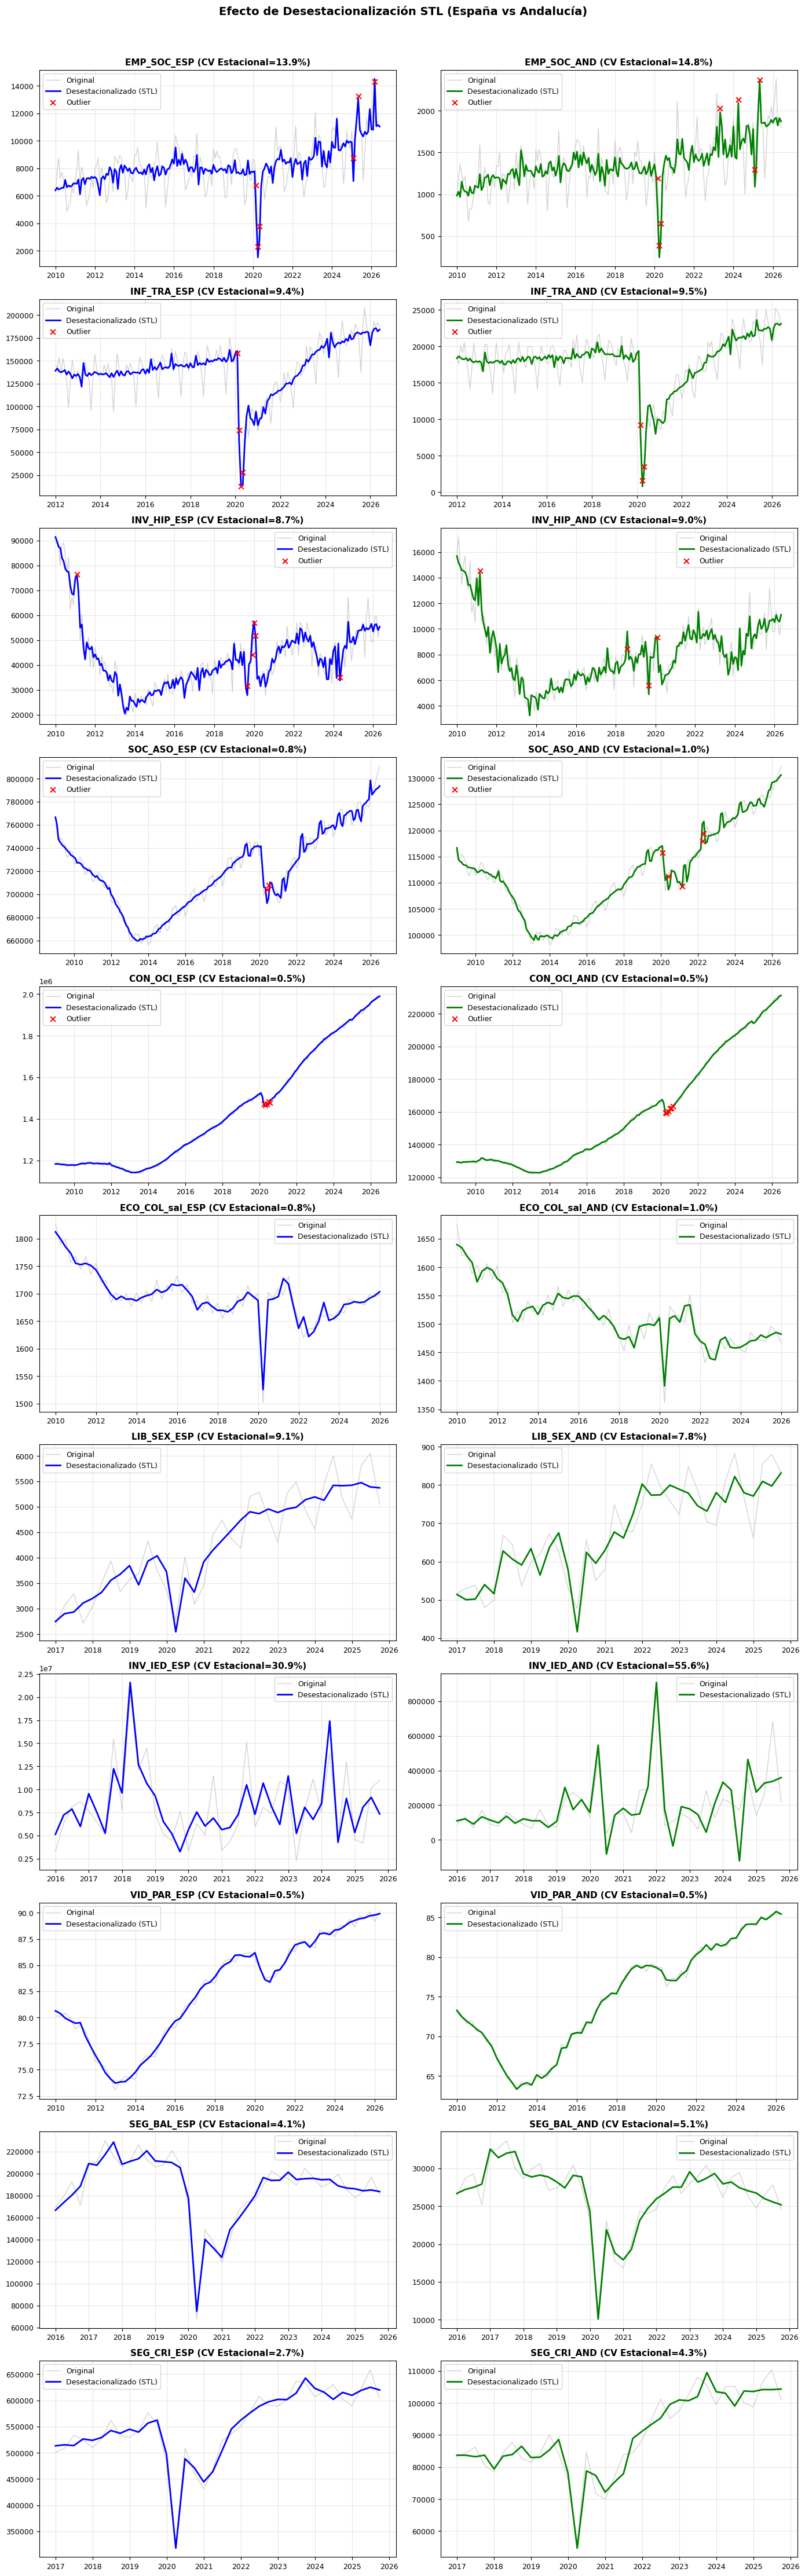

In [6]:
# %% CELDA 6B: VISUALIZACIÓN DESESTACIONALIZACIÓN (SOLO ESP Y AND)
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("VISUALIZACIÓN: ORIGINAL vs DESESTACIONALIZADO (ESP y AND)")
print("=" * 60)

# Filtrar solo series de ESP y AND
series_desest = [k for k in info_desest.keys() if k.endswith('_ESP') or k.endswith('_AND')]
n_series = len(series_desest)

if n_series == 0:
    print("⚠️ No hay series desestacionalizadas para visualizar.")
else:
    # Configuración de subplots (2 columnas)
    n_cols = 2
    n_rows = int(np.ceil(n_series / n_cols))
    
    # Ajustar altura para que no quede comprimido
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(series_desest):
        ax = axes[i]
        
        # Determinar si es mensual o trimestral
        if col in mensual.columns:
            orig = mensual_orig[col].dropna()
            desest = mensual[col].dropna()
            freq = 'M'
        else:
            orig = trimestral_orig[col].dropna()
            desest = trimestral[col].dropna()
            freq = 'T'
        
        # Convertir índice para plotear (Timestamp para matplotlib)
        if freq == 'T':
            x_orig = orig.index.to_timestamp()
            x_desest = desest.index.to_timestamp()
        else:
            x_orig = orig.index
            x_desest = desest.index
        
        # Plot Original (Gris tenue con marcadores para ver los datos reales)
        ax.plot(x_orig, orig.values, color='silver', alpha=0.7, linewidth=1, label='Original')
        
        # Plot Desestacionalizado (Color fuerte)
        color = 'green' if col.endswith('_AND') else 'blue'  # Verde Andalucía, Azul España
        ax.plot(x_desest, desest.values, color=color, linewidth=2, label='Desestacionalizado (STL)')
        
        # Marcar outliers detectados (si los hay)
        if 'outliers' in info_desest[col]:
            outliers = info_desest[col]['outliers']
            if len(outliers) > 0:
                # Filtrar outliers que estén en el índice
                idx_outliers = []
                val_outliers = []
                for o in outliers:
                    ot = o if freq == 'M' else o # En este contexto simple
                    # STL devuelve timestamps generalmente
                    # Buscamos correspondencia aproximada o exacta
                    try:
                        if ot in orig.index:
                            idx_outliers.append(ot.to_timestamp() if freq=='T' else ot)
                            val_outliers.append(orig.loc[ot])
                    except: pass
                
                if idx_outliers:
                    ax.scatter(idx_outliers, val_outliers, color='red', s=40, zorder=5, marker='x', label='Outlier')
        
        # Títulos y Leyenda
        cv = info_desest[col]['cv_estacional']
        ax.set_title(f"{col} (CV Estacional={cv:.1f}%)", fontsize=11, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        
    # Ocultar ejes vacíos si sobran cuadros
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Efecto de Desestacionalización STL (España vs Andalucía)', 
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    # Guardar
    import os
    os.makedirs('results/figures/analysis', exist_ok=True)
    plt.savefig('results/figures/analysis/ipa27_desestacionalizacion_esp_and.png', dpi=150, bbox_inches='tight', facecolor='white')
    print("\n✓ Gráfico guardado: results/figures/analysis/ipa27_desestacionalizacion_esp_and.png")
    plt.show()


VISUALIZACIÓN DOBLE EJE: ESP (Azul) vs AND (Rojo)


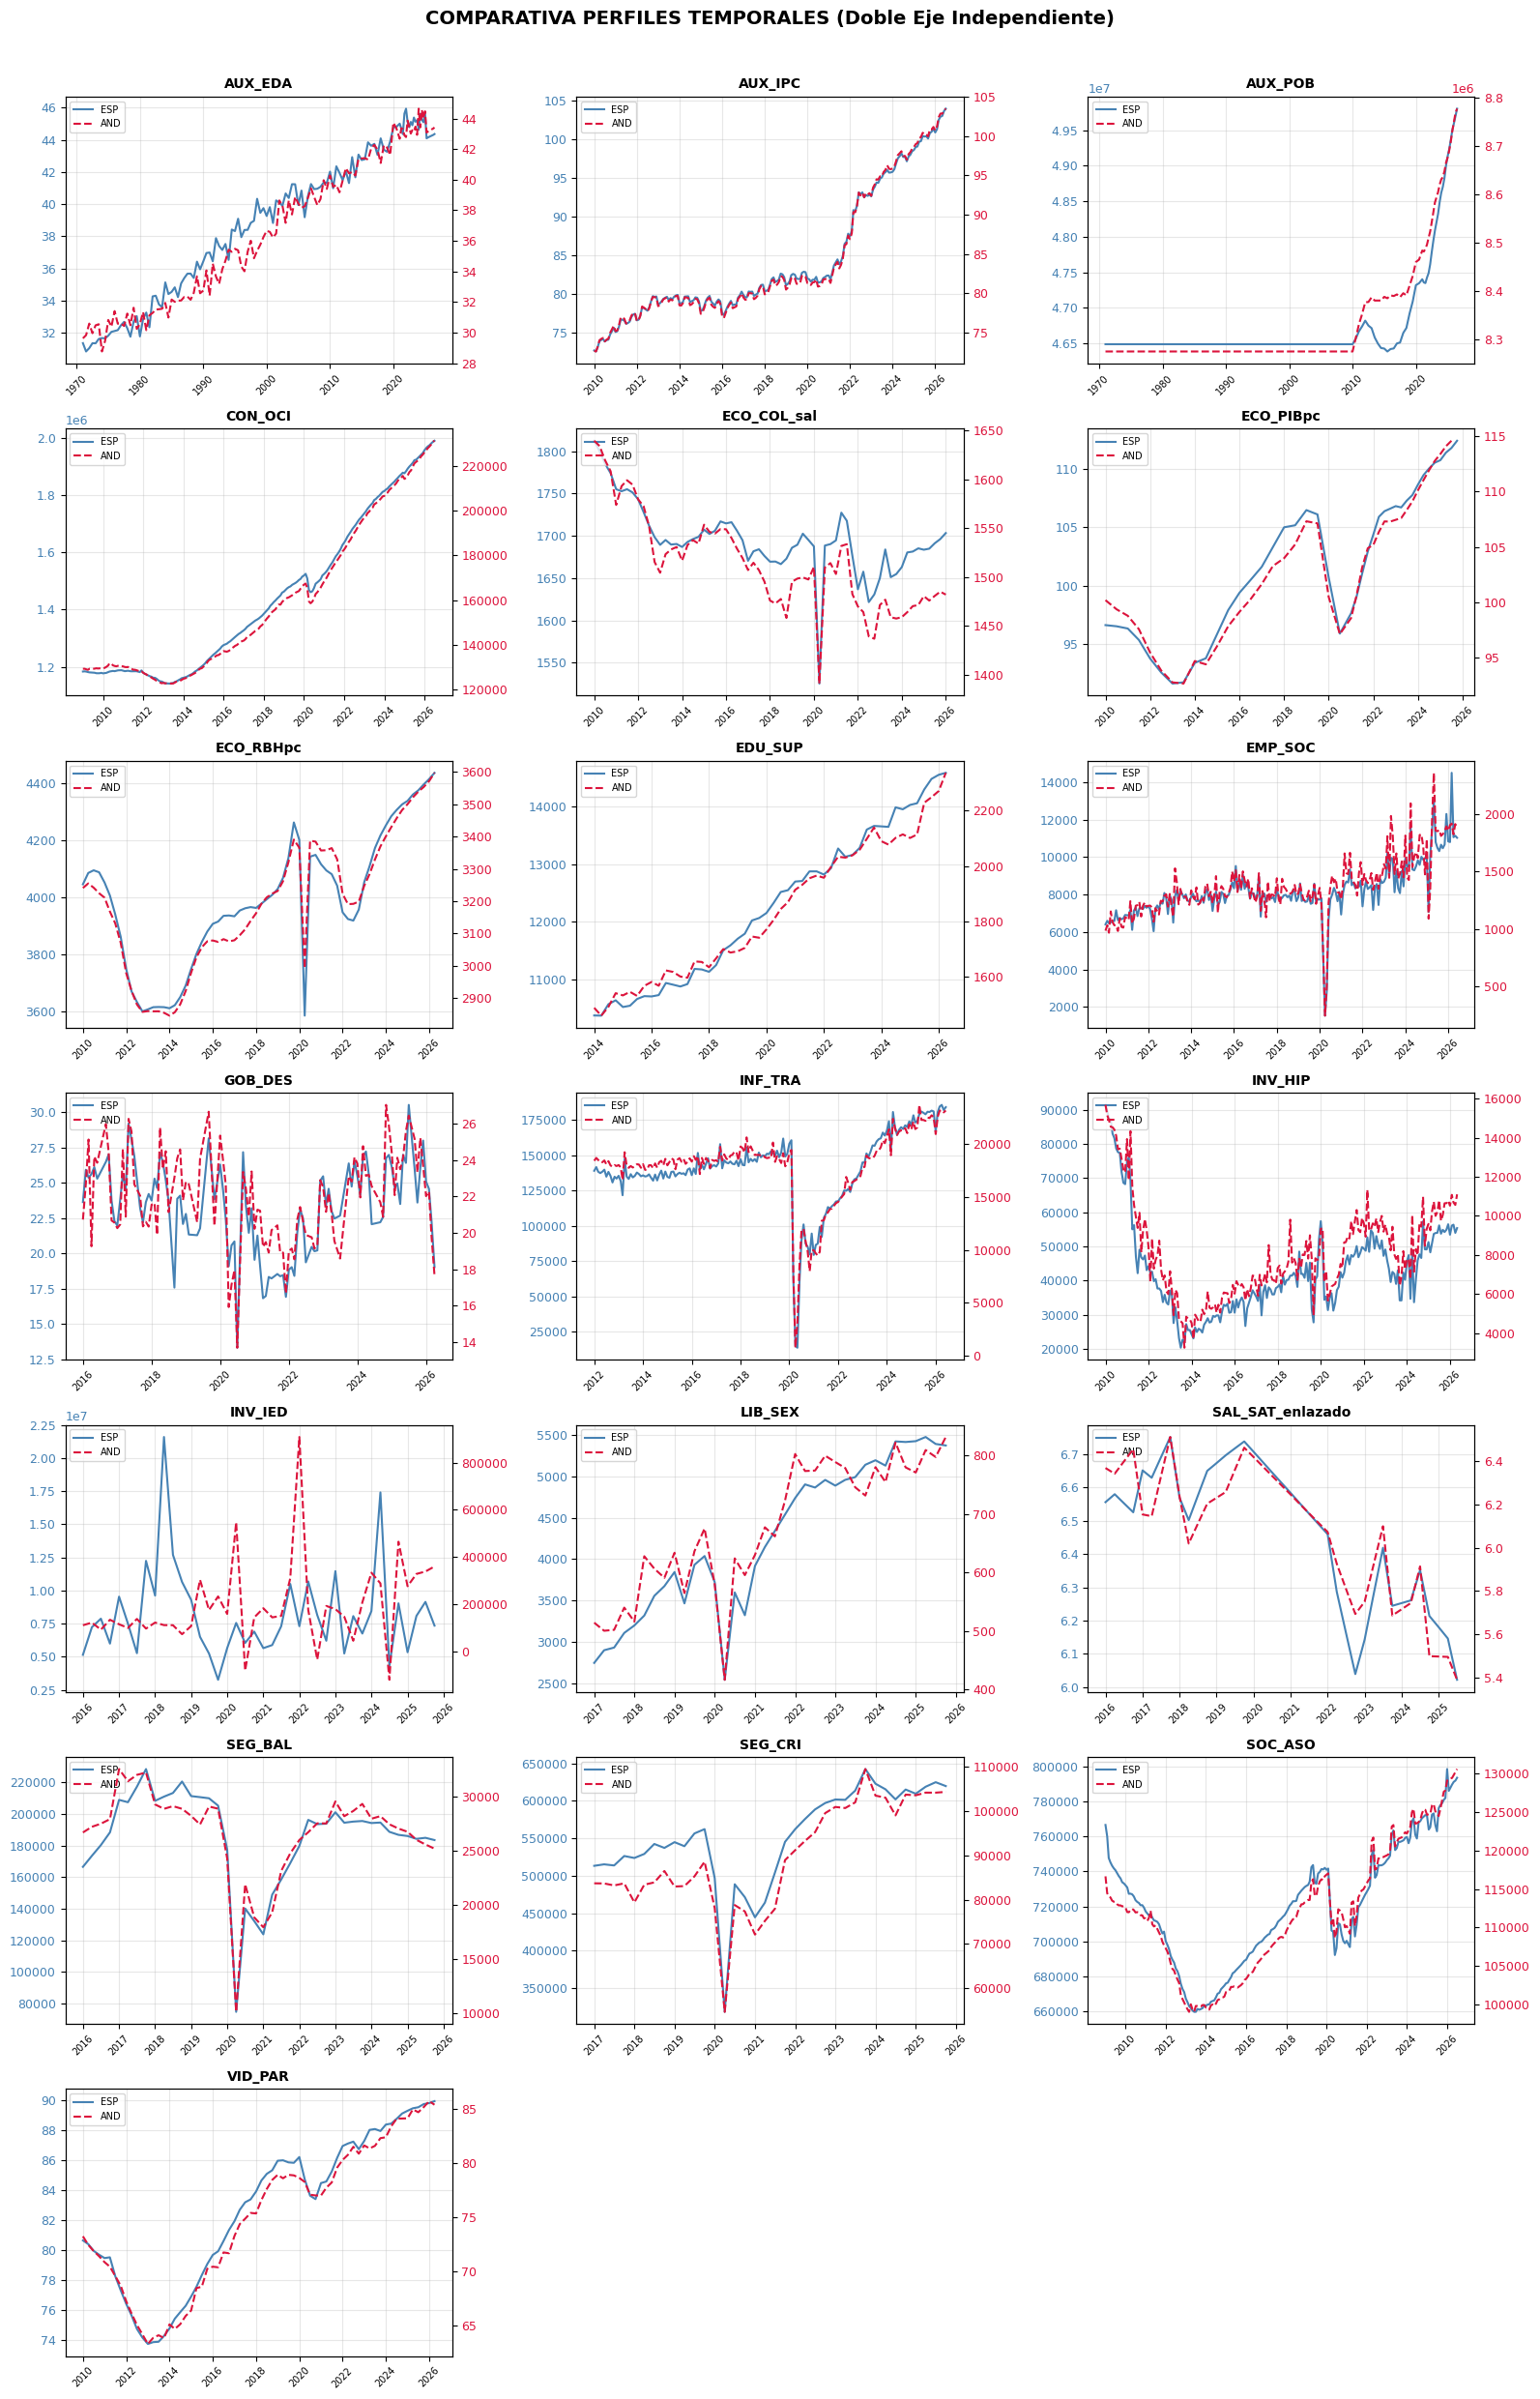

In [7]:
# %% CELDA 6B MODIFICADA: DOBLE EJE Y (ESP vs AND)
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("VISUALIZACIÓN DOBLE EJE: ESP (Azul) vs AND (Rojo)")
print("=" * 60)

cols_mensuales = [c for c in mensual.columns if c.endswith('_ESP') or c.endswith('_AND')]
cols_trimestrales = [c for c in trimestral.columns if c.endswith('_ESP') or c.endswith('_AND') if c not in cols_mensuales]
todas_cols = cols_mensuales + cols_trimestrales
indicadores_unicos = sorted(list(set([c.rsplit('_', 1)[0] for c in todas_cols])))

n_cols = 3
n_rows = int(np.ceil(len(indicadores_unicos) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, ind in enumerate(indicadores_unicos):
    ax1 = axes[i]
    col_esp = f"{ind}_ESP"
    col_and = f"{ind}_AND"
    
    # Eje Izquierdo (ESP) - Azul
    has_esp = False
    if col_esp in mensual.columns:
        s = mensual[col_esp].dropna()
        if not s.empty:
            ax1.plot(s.index, s.values, color='steelblue', label='ESP', linewidth=1.5)
            has_esp = True
    elif col_esp in trimestral.columns:
        s = trimestral[col_esp].dropna()
        if not s.empty:
            idx = s.index.to_timestamp() if hasattr(s.index, 'to_timestamp') else s.index
            ax1.plot(idx, s.values, color='steelblue', label='ESP', linewidth=1.5)
            has_esp = True
            
    # Eje Derecho (AND) - Rojo
    ax2 = ax1.twinx()
    has_and = False
    if col_and in mensual.columns:
        s = mensual[col_and].dropna()
        if not s.empty:
            ax2.plot(s.index, s.values, color='crimson', label='AND', linewidth=1.5, linestyle='--')
            has_and = True
    elif col_and in trimestral.columns:
        s = trimestral[col_and].dropna()
        if not s.empty:
            idx = s.index.to_timestamp() if hasattr(s.index, 'to_timestamp') else s.index
            ax2.plot(idx, s.values, color='crimson', label='AND', linewidth=1.5, linestyle='--')
            has_and = True
    
    # Estética
    ax1.set_title(ind, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    ax1.grid(True, alpha=0.3)
    
    # Colorear ejes para saber cual es cual
    ax1.tick_params(axis='y', labelcolor='steelblue')
    if has_and:
        ax2.tick_params(axis='y', labelcolor='crimson')
    else:
        ax2.set_visible(False) # Ocultar eje derecho si no hay Andalucía

    # Leyenda unificada (truco para twinx)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if lines1 or lines2:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=7)

# Ocultar vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"COMPARATIVA PERFILES TEMPORALES (Doble Eje Independiente)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Trimestralización

Convertimos todas las series a frecuencia trimestral:

### Mensuales → Trimestrales
- **Método**: Media de los 3 meses del trimestre
- **Resultado**: Series hasta 2025-Q3 (Q4 incompleto se descarta)

### Anuales → Trimestrales
- **Método principal**: Chow-Lin con indicador relacionado
- **Fallback**: Denton (spline cúbico) si no hay indicador

| Anual | Relacionado | Correlación |
|-------|-------------|-------------|
| CON_IDI | ECO_PIT | +0.64 |
| EDU_ABA | EDU_SUP | -0.96 |
| EMP_NAT | INF_TRA | +0.71 |
| INF_BAN | EDU_SUP | +0.94 |
| LIB_ODI | SEG_CRI | +0.77 |
| SAL_ESP | ECO_PIT | +0.88 |
| SOC_PAR_enlazado | EMP_SOC | -0.74 |
| VID_ARO | EDU_SUP | -0.71 |

In [9]:
# %% CELDA 7: TRIMESTRALIZACIÓN (ADAPTADA V2)
print("=" * 60)
print("TRIMESTRALIZACIÓN (V2 - Adaptada a estructura RBHpc)")
print("=" * 60)

# =============================================================================
# PASO 1: MENSUALES -> TRIMESTRALES
# =============================================================================
print("\n📊 PASO 1: Mensuales -> Trimestrales (agregación)")
print("-" * 50)

# Extensión ARIMA mensual previa para completar trimestres incompletos (ej: Hipotecas o Desafección)
target_month_end = Q_OBJETIVO.end_time.to_period('M').to_timestamp()
from statsmodels.tsa.arima.model import ARIMA

mensual.index = pd.to_datetime(mensual.index)
full_m_index = pd.date_range(mensual.index.min(), target_month_end, freq='MS')
mensual = mensual.reindex(full_m_index)

print("  🔧 Verificando completitud de series mensuales hasta", target_month_end.strftime('%Y-%m'), "...")
for col in mensual.columns:
    s_clean = mensual[col].dropna()
    if len(s_clean) > 0 and s_clean.index[-1] < target_month_end:
        ult_m = s_clean.index[-1]
        n_m = (target_month_end.year - ult_m.year) * 12 + (target_month_end.month - ult_m.month)
        if n_m > 0:
            fc_dates = pd.date_range(ult_m + pd.DateOffset(months=1), periods=n_m, freq='MS')
            try:
                mod = ARIMA(s_clean, order=(1, 1, 1))
                res_m = mod.fit()
                fc_vals = np.array(res_m.forecast(steps=n_m))
            except Exception:
                fc_vals = np.array([s_clean.iloc[-1]] * n_m)
            
            for dt, val in zip(fc_dates, fc_vals):
                mensual.loc[dt, col] = val
                
            print(f"     ✓ {col}: +{n_m}M [ARIMA Mensual] ({ult_m:%Y-%m} -> {target_month_end:%Y-%m})")

# Resample y filtrado
# Separar variables mensuales en flujo (suma) y stock (media)
mensuales_flujo = ['INV_HIP', 'EMP_SOC', 'INF_TRA']
mensuales_stock = ['GOB_DES', 'SOC_ASO', 'CON_OCI']

cols_flujo = [c for c in mensual.columns if any(c.startswith(ind) for ind in mensuales_flujo)]
cols_stock = [c for c in mensual.columns if any(c.startswith(ind) for ind in mensuales_stock)]
cols_resto = [c for c in mensual.columns if c not in cols_flujo and c not in cols_stock]

df_trims = []
if cols_flujo: df_trims.append(mensual[cols_flujo].resample('QE').sum())
if cols_stock: df_trims.append(mensual[cols_stock].resample('QE').mean())
if cols_resto: df_trims.append(mensual[cols_resto].resample('QE').mean())

if df_trims:
    mensual_trim = __import__('pandas').concat(df_trims, axis=1)
else:
    mensual_trim = mensual.resample('QE').mean()
mensual_trim.index = mensual_trim.index.to_period('Q')
mensual_trim = mensual_trim[mensual_trim.index <= Q_OBJETIVO]

print(f"  {len(mensual)} meses -> {len(mensual_trim)} trimestres")
print(f"  Rango: {mensual_trim.index.min()} -> {mensual_trim.index.max()}")

# =============================================================================
# PASO 2: ANUALES -> TRIMESTRALES (Chow-Lin / Denton)
# =============================================================================
print("\n📊 PASO 2: Anuales -> Trimestrales (Chow-Lin / Denton)")
print("-" * 50)
print("  Nota: ECO_RBHpc ya fue procesado en fase de Carga (Celda 2B)")

anuales_trim = {}
chowlin_betas = {}

# Lista de indicadores anuales a procesar
cols_anuales = [c for c in anual.columns if not c.startswith('AUX_')]
indicadores_anuales = sorted(list(set([c.rsplit('_', 1)[0] for c in cols_anuales])))

for ind in indicadores_anuales:
    # Saltar ECO_PIT o ECO_RBHpc si aparecieran en anual (ya tratados)
    if 'ECO_RBH' in ind or 'ECO_PIT' in ind:
        continue
    
    for terr in REGIONES:
        col = f"{ind}_{terr}"
        
        # Si ya existe en trimestral y está completa, saltar
        if col in trimestral.columns and not trimestral[col].dropna().empty:
            continue
            
        if col not in anual.columns:
            continue
            
        y_anual = anual[col].dropna()
        if len(y_anual) < 2:
            continue
            
        # Buscar configuración Chow-Lin
        config = CHOWLIN_CONFIG.get(ind, None)
        serie_trim = None
        
        if config:
            ind_rel = config['rel']
            # Mapeo de seguridad: Si la config pide ECO_PIT, le damos ECO_RBHpc
            if ind_rel == 'ECO_PIT': ind_rel = 'ECO_RBHpc'
            
            tipo = config.get('tipo', 'flujo')
            col_rel = f"{ind_rel}_{terr}"
            
            # Buscar indicador relacionado (benchmark)
            x_trim = None
            if col_rel in trimestral.columns:
                x_trim = trimestral[col_rel].dropna()
            elif col_rel in mensual_trim.columns:
                x_trim = mensual_trim[col_rel].dropna()
                
            if x_trim is not None and len(x_trim) >= 4:
                try:
                    # Usamos la función robusta (si está definida) o la simple
                    # Preferible usar chowlin_con_betas si existe (Celda 6)
                    if 'chowlin_con_betas' in globals():
                        serie_trim, beta = chowlin_con_betas(y_anual, x_trim, rho=0.5, tipo=tipo)
                        info_beta = beta[1]
                    elif 'chow_lin_ar1' in globals():
                        serie_trim = chow_lin_ar1(y_anual, x_trim)
                        info_beta = 0 # No devuelve beta esta versión
                    
                    if serie_trim is not None:
                        anuales_trim[col] = serie_trim
                        chowlin_betas[col] = {'ind_rel': ind_rel, 'tipo': tipo}
                        if terr in ['AND', 'ESP']:
                            print(f"  ✓ {col}: Chow-Lin {tipo} (con {ind_rel})")
                except Exception as e:
                    if terr in ['AND', 'ESP']:
                        print(f"  ⚠️ {col}: Chow-Lin falló ({e}), fallback Denton")
        
        # Fallback Denton
        if serie_trim is None:
            if 'denton_spline' in globals():
                 anuales_trim[col] = denton_spline(y_anual)
                 if terr in ['AND', 'ESP']:
                     print(f"  ✓ {col}: Denton (spline)")

print(f"\nTotal series anuales trimestralizadas: {len(anuales_trim)}")
print("✓ Trimestralización completada")



TRIMESTRALIZACIÓN (V2 - Adaptada a estructura RBHpc)

📊 PASO 1: Mensuales -> Trimestrales (agregación)
--------------------------------------------------
  🔧 Verificando completitud de series mensuales hasta 2026-06 ...
     ✓ GOB_DES_ESP: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_AND: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_ARA: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_AST: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_BAL: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_CAN: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_CANT: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_CAT: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_CLM: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_CYL: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_EXT: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_GAL: +2M [ARIMA Mensual] (2026-04 -> 2026-06)
     ✓ GOB_DES_MAD: +2M [ARIMA Mensual] (2026-0

## 6B. Visualización: Anual vs Trimestralizado

Comparamos las series anuales originales con el resultado de Chow-Lin/Denton:
- **Puntos grandes**: Valor anual original (centrado en julio de cada año)
- **Línea**: Serie trimestralizada
- La media de los 4 trimestres debe aproximarse al valor anual

VISUALIZACIÓN: ANUAL vs TRIMESTRALIZADO


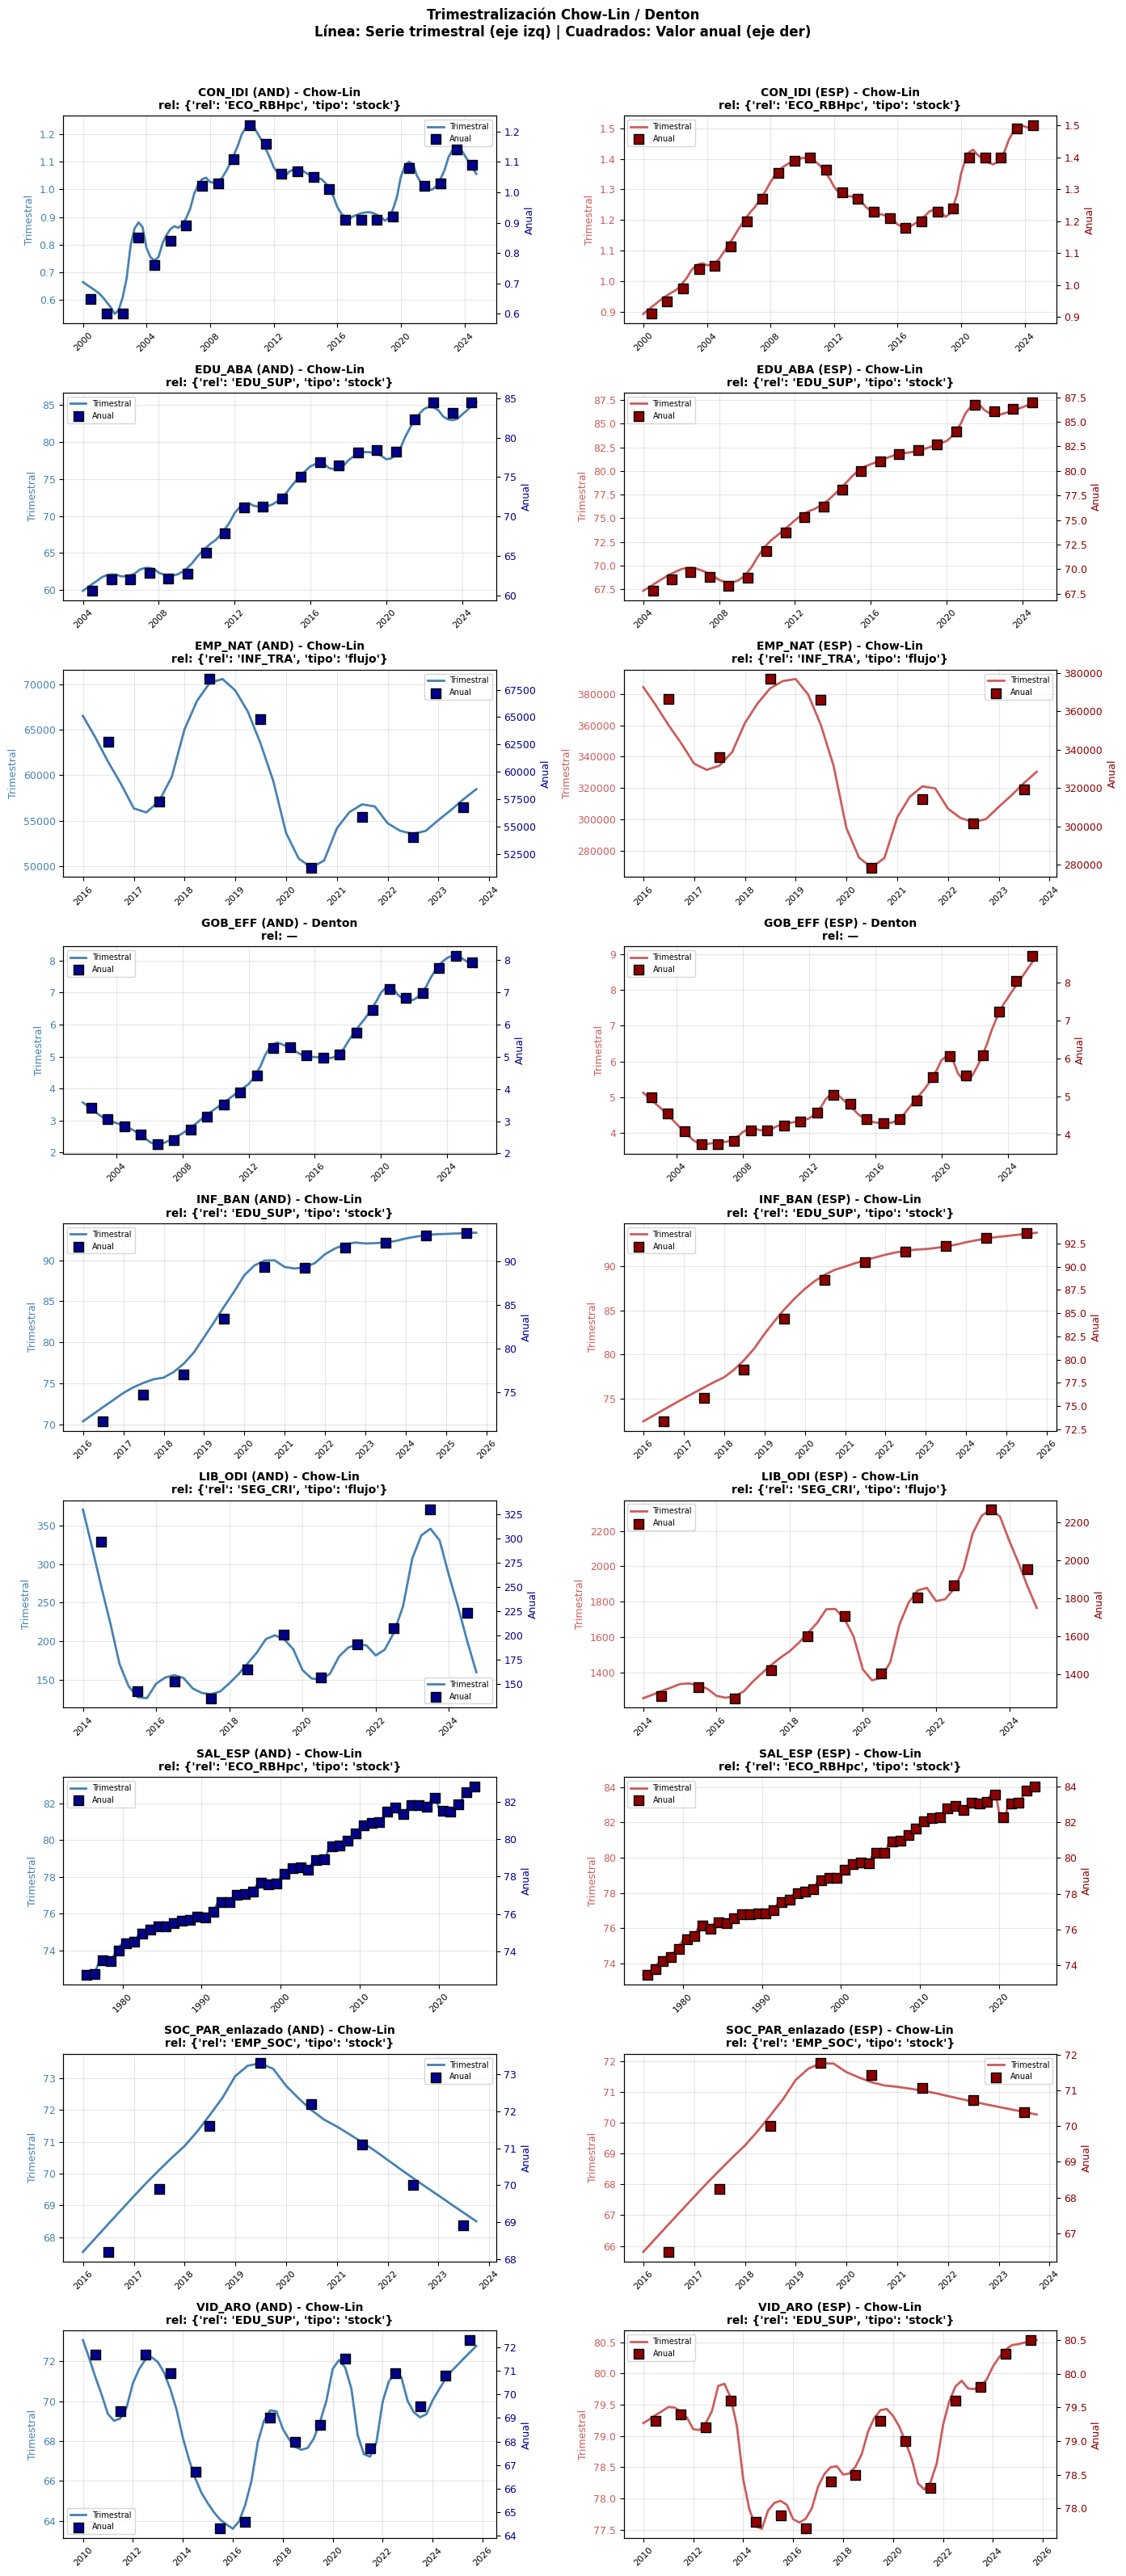


✓ Visualización completada


In [10]:
# %% CELDA 7B: VISUALIZACIÓN TRIMESTRALIZACIÓN
print("=" * 60)
print("VISUALIZACIÓN: ANUAL vs TRIMESTRALIZADO")
print("=" * 60)

# Indicadores anuales
indicadores_anuales = [col.replace('_AND', '') for col in anuales_trim.keys() if col.endswith('_AND')]
n_ind = len(indicadores_anuales)

fig, axes = plt.subplots(n_ind, 2, figsize=(14, 3.5 * n_ind))

for i, ind in enumerate(indicadores_anuales):
    
    for j, terr in enumerate(['AND', 'ESP']):
        ax1 = axes[i, j]
        ax2 = ax1.twinx()
        
        col = f"{ind}_{terr}"
        color_trim = 'steelblue' if terr == 'AND' else 'indianred'
        color_anual = 'darkblue' if terr == 'AND' else 'darkred'
        
        # --- Serie trimestral (eje izquierdo) ---
        if col in anuales_trim:
            trim = anuales_trim[col].dropna()
            x_trim = trim.index.to_timestamp()
            ax1.plot(x_trim, trim.values, color=color_trim, linewidth=2, label='Trimestral')
            ax1.set_ylabel('Trimestral', color=color_trim, fontsize=9)
            ax1.tick_params(axis='y', labelcolor=color_trim)
        
        # --- Serie anual (eje derecho) ---
        if col in anual.columns:
            anual_orig = anual[col].dropna()
            x_anual = [pd.Timestamp(year=año, month=7, day=1) for año in anual_orig.index]
            ax2.scatter(x_anual, anual_orig.values, s=80, color=color_anual, 
                       zorder=5, marker='s', edgecolor='black', linewidth=1, label='Anual')
            ax2.set_ylabel('Anual', color=color_anual, fontsize=9)
            ax2.tick_params(axis='y', labelcolor=color_anual)
        
        # Título
        metodo = "Chow-Lin" if ind in CHOWLIN_CONFIG else "Denton"
        relacionado = CHOWLIN_CONFIG.get(ind, "—")
        ax1.set_title(f"{ind} ({terr}) - {metodo}\nrel: {relacionado}", fontsize=10, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45, labelsize=8)
        
        # Leyenda
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=7)

plt.suptitle('Trimestralización Chow-Lin / Denton\n'
             'Línea: Serie trimestral (eje izq) | Cuadrados: Valor anual (eje der)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/analysis/ipa27_trimestralizacion.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Visualización completada")


## 7. Nowcasting (Extensión ARIMA)

Extendemos las series que no llegan hasta 2025-Q3 usando ARIMA automático.

**Proceso**:
1. Identificar series que terminan antes del objetivo
2. Ajustar modelo ARIMA (p,d,q) automáticamente con `pmdarima`
3. Pronosticar los trimestres faltantes
4. Si ARIMA falla, usar LOCF (Last Observation Carried Forward)

In [11]:
# %% CELDA 8: NOWCASTING (SIMPLIFICADO - TODO ARIMA)
print("=" * 60)
print("NOWCASTING - EXTENSIÓN DE SERIES (ARIMA)")
print("=" * 60)

# =============================================================================
# CÁLCULO AUTOMÁTICO DEL TRIMESTRE OBJETIVO
# =============================================================================
from datetime import datetime
# from pmdarima import auto_arima # Asegurarse de tener importada pmdarima arriba o usar fallback

now = datetime.now()
month = now.month
year = now.year

print(f"Mes actual: {now.strftime('%B %Y')}")
print(f"Objetivo calculado: {Q_OBJETIVO}\n")

# =============================================================================
# PASO 1: Extender anuales trimestralizadas
# =============================================================================
print("📊 ANUALES TRIMESTRALIZADAS (Extensión ARIMA)")
print("-" * 50)

count_ext = 0
for col, serie in anuales_trim.items():
    serie = serie.dropna()
    if len(serie) == 0: continue
    
    ultimo = serie.index[-1]
    if ultimo < Q_OBJETIVO:
        try:
            # Asumimos que extender_arima está definida en celdas anteriores
            ext = extender_arima(serie, Q_OBJETIVO)
            n_ext = len(ext) - len(serie)
            if n_ext > 0:
                anuales_trim[col] = ext
                count_ext += 1
                
                # Detalle AND/ESP
                terr = col.split('_')[-1]
                if terr in ['AND', 'ESP']:
                    print(f"  ✓ {col}: +{n_ext}Q [ARIMA] ({ultimo} -> {Q_OBJETIVO})")
        except Exception as e:
            print(f"  ❌ Error extendiendo {col}: {e}")

print(f"Total anuales extendidas: {count_ext}")

# =============================================================================
# PASO 2: Extender trimestrales originales (ARIMA)
# =============================================================================
print("\n📊 TRIMESTRALES ORIGINALES (ARIMA)")
print("-" * 50)

for col in trimestral.columns:
    if col.startswith('AUX_'): continue
    
    serie = trimestral[col].dropna()
    if len(serie) == 0: continue
    
    ultimo = serie.index[-1]
    if ultimo < Q_OBJETIVO:
        try:
            trimestral[col] = extender_arima(serie, Q_OBJETIVO)
            terr = col.split('_')[-1]
            if terr in ['AND', 'ESP']:
                n_ext = (Q_OBJETIVO.year - ultimo.year)*4 + (Q_OBJETIVO.quarter - ultimo.quarter)
                print(f"  ✓ {col}: +{n_ext}Q [ARIMA] ({ultimo} -> {Q_OBJETIVO})")
        except Exception as e:
             print(f"  ❌ Error trimestral {col}: {e}")

# =============================================================================
# PASO 3: Extender mensuales agregadas
# =============================================================================
print("\n📊 MENSUALES AGREGADAS")
print("-" * 50)

for col in mensual_trim.columns:
    if col.startswith('AUX_'): continue
    
    serie = mensual_trim[col].dropna()
    if len(serie) == 0: continue
    
    ultimo = serie.index[-1]
    if ultimo < Q_OBJETIVO:
        try:
            mensual_trim[col] = extender_arima(serie, Q_OBJETIVO)
            terr = col.split('_')[-1]
            if terr in ['AND', 'ESP']:
                n_ext = len(mensual_trim[col]) - len(serie)
                print(f"  ✓ {col}: +{n_ext}Q [ARIMA]")
        except Exception as e:
            print(f"  ❌ Error mensual {col}: {e}")

print("\n✓ Nowcasting completado")


# CLIP FINAL para seguridad
trimestral = trimestral[trimestral.index <= Q_OBJETIVO]



NOWCASTING - EXTENSIÓN DE SERIES (ARIMA)
Mes actual: August 2026
Objetivo calculado: 2026Q2

📊 ANUALES TRIMESTRALIZADAS (Extensión ARIMA)
--------------------------------------------------
  ✓ CON_IDI_ESP: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ CON_IDI_AND: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ EDU_ABA_ESP: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ EDU_ABA_AND: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ EMP_NAT_ESP: +10Q [ARIMA] (2023Q4 -> 2026Q2)
  ✓ EMP_NAT_AND: +10Q [ARIMA] (2023Q4 -> 2026Q2)
  ✓ GOB_EFF_ESP: +2Q [ARIMA] (2025Q4 -> 2026Q2)
  ✓ GOB_EFF_AND: +2Q [ARIMA] (2025Q4 -> 2026Q2)
  ✓ INF_BAN_ESP: +2Q [ARIMA] (2025Q4 -> 2026Q2)
  ✓ INF_BAN_AND: +2Q [ARIMA] (2025Q4 -> 2026Q2)
  ✓ LIB_ODI_ESP: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ LIB_ODI_AND: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ SAL_ESP_ESP: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ SAL_ESP_AND: +6Q [ARIMA] (2024Q4 -> 2026Q2)
  ✓ SOC_PAR_enlazado_ESP: +10Q [ARIMA] (2023Q4 -> 2026Q2)
  ✓ SOC_PAR_enlazado_AND: +10Q [ARIMA] (2023Q4 -> 2026Q2)
  ✓ VID_ARO_ESP: +2Q 

## 8B. Visualización: Series Extendidas

Comparamos la serie original vs la extensión (Chow-Lin o ARIMA):
- **Línea sólida**: Datos originales
- **Línea punteada**: Extensión (nowcasting)
- Rango: desde 2022 para ver contexto

Columnas: AND | ESP

In [12]:
# %% SUAVIZADO DE INDICADORES VOLÁTILES (Pre-Normalización)
print("=" * 60)
print("SUAVIZADO TEMPORAL (Rolling Mean 4 Trimestres) para Inversión y Gobernanza")
print("=" * 60)

# Indicadores a suavizar (Eventos raros o muy volátiles)
# Añadimos INV_IED para estabilizar la media geométrica
SMOOTH_VARS = ['GOB_EFF', 'INV_IED']

suavizados = 0

# Identificar el DataFrame actual de trabajo
target_df = None
if 'trimestral' in locals():
    target_df = trimestral
elif 'df_trim' in locals():
    target_df = df_trim

if target_df is None:
    print("⚠️ DataFrame de datos no encontrado. No se puede suavizar.")
else:
    for ind in SMOOTH_VARS:
        cols = [c for c in target_df.columns if c.startswith(f"{ind}_")]
        for col in cols:
            # Media móvil de 4 periodos (1 año) para captar la tendencia real
            # min_periods=1 para no perder los datos de los primeros trimestres
            target_df[col] = target_df[col].rolling(window=4, min_periods=1).mean()
            suavizados += 1

    print(f"✓ Suavizado aplicado a {suavizados} series territoriales ({SMOOTH_VARS})")
    print("  (Esto evitará que caídas puntuales de la IED hundan el índice por la naturaleza de la media geométrica)")


SUAVIZADO TEMPORAL (Rolling Mean 4 Trimestres) para Inversión y Gobernanza
✓ Suavizado aplicado a 18 series territoriales (['GOB_EFF', 'INV_IED'])
  (Esto evitará que caídas puntuales de la IED hundan el índice por la naturaleza de la media geométrica)


## 3. Normalización Per Cápita

Varios indicadores vienen en valores absolutos (número de delitos, sociedades creadas, etc.) y no son comparables entre territorios con diferente población.

**Transformación**: `valor_normalizado = (valor / población) × factor`

| Indicador | Factor | Resultado |
|-----------|--------|-----------|
| SEG_BAL, SEG_CRI, LIB_SEX, LIB_ODI | ×100.000 | Tasa por 100k hab |
| EMP_SOC, EMP_NAT, INV_HIP | ×100.000 | Por 100k hab |
| INF_TRA | ×1.000 | Viajeros por 1k hab |
| INV_IED | ×1 | € per cápita |

La población se obtiene de `AUX_POB` (serie trimestral para las 18 regiones).

In [13]:
# %% CELDA 4: NORMALIZACIÓN PER CÁPITA (CORREGIDA)
print("=" * 60)
print("NORMALIZACIÓN PER CÁPITA (18 Regiones)")
print("=" * 60)

# 0. CAPTURAR MUESTRA PARA AUDITORÍA (Antes de modificar)
sample_ind = 'SEG_BAL_AND'
sample_val_pre = None
sample_pob = None
if sample_ind in trimestral.columns:
    sample_val_pre = trimestral[sample_ind].dropna().iloc[-1]
    if 'AUX_POB_AND' in trimestral.columns:
        sample_pob = trimestral['AUX_POB_AND'].loc[trimestral[sample_ind].dropna().index[-1]]
    elif 'AUX_POB_enlazado_AND' in trimestral.columns:
        sample_pob = trimestral['AUX_POB_enlazado_AND'].loc[trimestral[sample_ind].dropna().index[-1]]

# 1. CONFIGURACIÓN CORREGIDA
PER_CAPITA_CONFIG = {
    'SEG_BAL': 'POB',   # Balance criminalidad -> tasa x 100k hab
    'SEG_CRI': 'POB',   # Tasa criminalidad -> tasa x 100k hab
    'LIB_SEX': 'POB',   # Delitos sexuales -> tasa x 100k hab
    'LIB_ODI': 'POB',   # Delitos odio -> tasa x 100k hab
    'EDU_SUP': 'POB',   # Educación superior -> tasa x 100 hab (%)
    'EMP_SOC': 'POB',   # Sociedades mercantiles -> x 100k hab
    'EMP_NAT': 'POB',   # Nacimientos empresas -> x 100k hab
    'INV_HIP': 'POB',   # Hipotecas -> x 100k hab
    'INF_TRA': 'POB',   # Pasajeros transporte -> x 1k hab
    'SOC_ASO': 'POB',   # Asociaciones -> x 1k hab
    'CON_OCI': 'POB',   # Afiliados conocimiento intensivo -> x 1k hab (CORREGIDO)
    'INV_IED': 'PIB',   # Inversión extranjera directa -> % RBH (proxy PIB)
}

# Factores de escala
FACTORES_CONVERSION = {
    'SEG_CRI': 100_000, 'SEG_BAL': 100_000, 'LIB_SEX': 100_000, 'LIB_ODI': 100_000,
    'EMP_SOC': 100_000, 'EMP_NAT': 100_000, 'INV_HIP': 100_000,
    'INF_TRA': 1_000,   'SOC_ASO': 1_000,   'CON_OCI': 1_000,
    'EDU_SUP': 100,     'INV_IED': 100  # Para INV_IED: resultado en % de RBH (proxy PIB)
}

normalizados = 0
errores = []

for ind, denom_tipo in PER_CAPITA_CONFIG.items():
    factor = FACTORES_CONVERSION.get(ind, 1)
    
    for terr in REGIONES:
        col = f"{ind}_{terr}"
        
        # Buscar DataFrame objetivo
        target_df = None
        if col in trimestral.columns:
            target_df = trimestral
        elif 'mensual_trim' in globals() and col in mensual_trim.columns:
            target_df = mensual_trim
        elif col in anuales_trim:
            target_df = None  # Caso especial dict
        else:
            continue
        
        # === SELECCIONAR DENOMINADOR ===
        if denom_tipo == 'PIB':
            # Reconstruir PIB TOTAL = PIBpc * Población / 1000 (en millones €)
            col_pibpc = f"ECO_RBHpc_{terr}"
            col_pob = f"AUX_POB_{terr}"
            if col_pob not in trimestral.columns:
                col_pob = f"AUX_POB_enlazado_{terr}"
            
            if col_pibpc not in trimestral.columns or col_pob not in trimestral.columns:
                errores.append(f"{col}: No se puede reconstruir PIB (faltan PIBpc o POB)")
                continue
            
            # PIB total en millones de euros
            denom = (trimestral[col_pibpc] * trimestral[col_pob]) / 1_000_000
            
        else:  # 'POB'
            col_denom = f"AUX_POB_{terr}"
            if col_denom not in trimestral.columns:
                col_denom = f"AUX_POB_enlazado_{terr}"
            
            if col_denom not in trimestral.columns:
                errores.append(f"{col}: No se encuentra población")
                continue
            
            denom = trimestral[col_denom]
        
        # === APLICAR NORMALIZACIÓN ===
        if target_df is not None:
            serie = target_df[col]
            denom_aligned = denom.reindex(serie.index)
            target_df[col] = (serie / denom_aligned) * factor
            normalizados += 1
        elif col in anuales_trim:
            serie = anuales_trim[col]
            denom_aligned = denom.reindex(serie.index)
            anuales_trim[col] = (serie / denom_aligned) * factor
            normalizados += 1

print(f"✓ Normalización completada: {normalizados} series procesadas")

if errores:
    print(f"\n⚠️ Errores ({len(errores)}):")
    for e in errores[:5]:
        print(f"  - {e}")

# 3. AUDITORÍA FINAL
if sample_val_pre is not None and sample_pob is not None:
    sample_val_post = trimestral[sample_ind].dropna().iloc[-1]
    print("\n--- 🔍 AUDITORÍA DE NORMALIZACIÓN (Ejemplo: SEG_BAL_AND) ---")
    print(f"  1. Valor Original (Absoluto): {sample_val_pre:,.0f}")
    print(f"  2. Población Trimestral:      {sample_pob:,.0f}")
    print(f"  3. Factor Escala:             x100,000")
    calc_manual = (sample_val_pre / sample_pob) * 100_000
    print(f"  4. Cálculo Manual:            {calc_manual:.4f}")
    print(f"  5. Resultado en DataFrame:    {sample_val_post:.4f}")
    
    if abs(calc_manual - sample_val_post) < 0.01:
        print("  ✅ LA OPERACIÓN ES CORRECTA")
    else:
        print("  ❌ DISCREPANCIA DETECTADA")

# 4. AUDITORÍA INV_IED (Nuevo)
print("\n--- 🔍 AUDITORÍA INV_IED_AND (% de RBH, proxy PIB) ---")
if 'INV_IED_AND' in trimestral.columns:
    val_ied = trimestral['INV_IED_AND'].dropna().iloc[-1]
    print(f"  Último valor: {val_ied:.4f}%")
    if val_ied < 50:  # Debería ser un porcentaje razonable
        print("  ✅ Valor razonable (% de RBH, proxy PIB)")
    else:
        print("  ⚠️ Valor sospechosamente alto")

NORMALIZACIÓN PER CÁPITA (18 Regiones)
✓ Normalización completada: 216 series procesadas

--- 🔍 AUDITORÍA DE NORMALIZACIÓN (Ejemplo: SEG_BAL_AND) ---
  1. Valor Original (Absoluto): 25,890
  2. Población Trimestral:      8,769,370
  3. Factor Escala:             x100,000
  4. Cálculo Manual:            295.2361
  5. Resultado en DataFrame:    295.2361
  ✅ LA OPERACIÓN ES CORRECTA

--- 🔍 AUDITORÍA INV_IED_AND (% de RBH, proxy PIB) ---
  Último valor: 860.0576%
  ⚠️ Valor sospechosamente alto


## 9. Unificación

Combinamos todas las series en un único DataFrame trimestral:

1. **Base**: Series trimestrales originales
2. **Añadir**: Series mensuales agregadas
3. **Añadir**: Series anuales trimestralizadas

Resultado: DataFrame con todos los indicadores listos para normalizar.

In [14]:
# %% CELDA 9: UNIFICACIÓN
print("=" * 60)
print("UNIFICACIÓN EN DATAFRAME TRIMESTRAL")
print("=" * 60)

# Empezar con trimestrales originales
df_trim = trimestral.copy()

print(f"\n1️⃣ Base (trimestrales): {len(df_trim.columns)} columnas")

# Añadir mensuales agregadas
n_añadidas = 0
for col in mensual_trim.columns:
    if col not in df_trim.columns:
        df_trim[col] = mensual_trim[col]
        n_añadidas += 1
    else:
        df_trim[col] = df_trim[col].combine_first(mensual_trim[col])

print(f"2️⃣ + Mensuales agregadas: +{n_añadidas} columnas nuevas")

# Añadir anuales trimestralizadas
n_añadidas = 0
for col, serie in anuales_trim.items():
    if col not in df_trim.columns:
        df_trim[col] = serie
        n_añadidas += 1
    else:
        df_trim[col] = df_trim[col].combine_first(serie)

print(f"3️⃣ + Anuales trimestralizadas: +{n_añadidas} columnas nuevas")

# Ordenar índice
df_trim = df_trim.sort_index()
# Limitar al trimestre objetivo
df_trim = df_trim[df_trim.index <= Q_OBJETIVO]

# Separar columnas
cols_aux = [c for c in df_trim.columns if c.startswith('AUX_')]
cols_ind = [c for c in df_trim.columns if not c.startswith('AUX_')]

# Ordenar columnas
df_trim = df_trim[sorted(cols_ind) + sorted(cols_aux)]

# =============================================================================
# RESUMEN
# =============================================================================
print(f"\n" + "=" * 60)
print("DATAFRAME UNIFICADO")
print("=" * 60)
print(f"  Shape: {df_trim.shape}")
print(f"  Rango: {df_trim.index.min()} → {df_trim.index.max()}")
print(f"  Indicadores: {len(cols_ind)}")
print(f"  Auxiliares: {len(cols_aux)}")

# Indicadores únicos
indicadores_unicos = sorted(set(c.rsplit('_', 1)[0] for c in cols_ind))
print(f"\n  Indicadores únicos ({len(indicadores_unicos)}):")
for ind in indicadores_unicos:
    # Usar AND como referencia para el resumen de cobertura
    col_ref = f"{ind}_AND"
    if col_ref not in df_trim.columns:
        # Si no hay AND, buscar la primera región disponible
        regiones_disp = [c for c in df_trim.columns if c.startswith(f"{ind}_")]
        if regiones_disp:
            col_ref = regiones_disp[0]
        else:
            continue
            
    serie = df_trim[col_ref].dropna()
    rango = f"{serie.index.min()} → {serie.index.max()}" if len(serie) > 0 else "SIN DATOS"
    n_obs = len(serie)
    print(f"    {ind:<20} {rango} ({n_obs} obs)")

# Verificación cobertura (usando AND como referencia o ESP si AND falta)
print(f"\n" + "-" * 60)
print(f"COBERTURA AL {Q_OBJETIVO} (Ref: AND/ESP)")
print("-" * 60)

completos, incompletos = [], []
for ind in indicadores_unicos:
    col_ref = f"{ind}_AND"
    if col_ref not in df_trim.columns:
        col_ref = f"{ind}_ESP"
        
    if col_ref in df_trim.columns:
        serie = df_trim[col_ref].dropna()
        if len(serie) > 0 and serie.index[-1] >= Q_OBJETIVO:
            completos.append(ind)
        else:
            incompletos.append(ind)
    else:
        incompletos.append(ind)

print(f"  ✅ Completos: {len(completos)}")
print(f"  ❌ Incompletos: {len(incompletos)}")
if incompletos:
    print(f"     → {incompletos}")

print("\n✓ Unificación completada")

UNIFICACIÓN EN DATAFRAME TRIMESTRAL

1️⃣ Base (trimestrales): 216 columnas
2️⃣ + Mensuales agregadas: +126 columnas nuevas
3️⃣ + Anuales trimestralizadas: +162 columnas nuevas

DATAFRAME UNIFICADO
  Shape: (174, 504)
  Rango: 1971Q1 → 2026Q2
  Indicadores: 450
  Auxiliares: 54

  Indicadores únicos (25):
    CON_IDI              2000Q1 → 2026Q2 (106 obs)
    CON_OCI              2009Q1 → 2026Q2 (70 obs)
    ECO_COL_sal          2010Q1 → 2026Q2 (66 obs)
    ECO_PIBpc            2010Q1 → 2026Q2 (44 obs)
    ECO_RBHpc            2010Q1 → 2026Q2 (66 obs)
    EDU_ABA              2004Q1 → 2026Q2 (90 obs)
    EDU_SUP              2014Q1 → 2026Q2 (50 obs)
    EMP_NAT              2016Q1 → 2026Q2 (42 obs)
    EMP_SOC              2009Q1 → 2026Q2 (70 obs)
    GOB_DES              2016Q1 → 2026Q2 (42 obs)
    GOB_EFF              2002Q1 → 2026Q2 (98 obs)
    INF_BAN              2016Q1 → 2026Q2 (42 obs)
    INF_TRA              2009Q1 → 2026Q2 (70 obs)
    INV_HIP              2009Q1 → 2026Q2 (7

In [15]:
# =============================================================================
# GUARDADO DE DATAFRAME MODELADO Y UNIFICADO PARA EL BLOQUE 3 (Exportación)
# =============================================================================
import os

os.makedirs('data/processed', exist_ok=True)
df_trim.to_csv('data/processed/ipa27_modeled_raw.csv')

print("✓ DataFrame modelado y consolidado guardado correctamente:")
print("  - data/processed/ipa27_modeled_raw.csv")


✓ DataFrame modelado y consolidado guardado correctamente:
  - data/processed/ipa27_modeled_raw.csv
